### **Análisis exploratorio de datos**

##### Importar librerias

In [621]:
# Importar librerias
import pandas as pd
from datetime import datetime
import unicodedata
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

##### Importar bases de datos

In [530]:
df_orders = pd.read_csv('db/data_orders_altered.csv')

df_stores = pd.read_csv('db/data_stores_altered - data_stores_altered.csv')

In [531]:
df_orders.head()

,store_id_anon,created_date,app_origin,PROMEDIO_SHIPPING_COST,FREE_SHIPPING_FLAG,tpn_altered,tpv_altered,gmv_lc_altered
0,111106.0,2024-01-03,MP_ANDROID_WALLET,1025.54,0,5,15523.62,16553.07
1,112508.0,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,136026.49,62786.91
2,113999.0,2024-01-03,MP_ANDROID_WALLET,1025.54,1,4,53376.80,25403.86
3,103068.0,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,27065.79,26522.44
4,105203.0,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,33278.93,33922.98


In [532]:
df_stores.head()

,BRAND_ID_ANON,STORE_ID_ANON,CREATION_DATE,STATUS,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
0,14295.0,112719,2025-08-19T15:18:27.939Z,active,Microstores,42.0,3P,New brand,Ramos Mejía,Buenos Aires,10 min,No
1,11797.0,103934,2025-08-19T15:17:10.071Z,active,Microstores,42.0,3P,New brand,Centro,Rosario,15 min,Sí
2,11999.0,113756,2025-08-19T15:09:21.276Z,active,Microstores,42.0,3P,New brand,San Nicolás,Capital Federal,15 min,Sí
3,12320.0,104678,2025-08-19T15:07:43.231Z,active,Microstores,37.5,3P,New brand,La Plata,Buenos Aires,25 min,Sí
4,12014.0,109662,2025-08-19T14:58:23.237Z,active,Microstores,42.0,3P,New brand,Centro,Rosario,20 min,Sí


In [533]:
df_orders.columns

Index(['store_id_anon', 'created_date', 'app_origin', 'PROMEDIO_SHIPPING_COST',
       'FREE_SHIPPING_FLAG', 'tpn_altered', 'tpv_altered', 'gmv_lc_altered'],
      dtype='object')

In [534]:
df_stores.columns

Index(['BRAND_ID_ANON', 'STORE_ID_ANON', 'CREATION_DATE', 'STATUS', 'segmento',
       'comision_actual', 'logistic_type', 'store_type', 'barrio', 'ciudad',
       'cooking_time', 'tiene_otra_app'],
      dtype='object')

In [535]:
# Renombrar columnas para practicidad

df_orders.rename(columns={'store_id_anon': 'store_id',
                          'created_date': 'orders_date',
                          'PROMEDIO_SHIPPING_COST': 'avg_shipping_cost',
                          'FREE_SHIPPING_FLAG': 'free_shipping',
                          'tpn_altered': 'total_products_number',
                          'tpv_altered': 'total_products_value',
                          'gmv_lc_altered': 'gross_merchant_value'
                          }, inplace=True)

df_stores.rename(columns={'BRAND_ID_ANON': 'brand_id',
                          'STORE_ID_ANON': 'store_id',
                          'CREATION_DATE': 'creation_date'
                          }, inplace=True)

#### Columnas de *df_stores*

##### *status*

In [536]:
df_stores.head()

,brand_id,store_id,creation_date,STATUS,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
0,14295.0,112719,2025-08-19T15:18:27.939Z,active,Microstores,42.0,3P,New brand,Ramos Mejía,Buenos Aires,10 min,No
1,11797.0,103934,2025-08-19T15:17:10.071Z,active,Microstores,42.0,3P,New brand,Centro,Rosario,15 min,Sí
2,11999.0,113756,2025-08-19T15:09:21.276Z,active,Microstores,42.0,3P,New brand,San Nicolás,Capital Federal,15 min,Sí
3,12320.0,104678,2025-08-19T15:07:43.231Z,active,Microstores,37.5,3P,New brand,La Plata,Buenos Aires,25 min,Sí
4,12014.0,109662,2025-08-19T14:58:23.237Z,active,Microstores,42.0,3P,New brand,Centro,Rosario,20 min,Sí


In [537]:
pd.DataFrame({'count': df_stores['STATUS'].value_counts(dropna=False), 'percentage': (df_stores['STATUS'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
STATUS,,
active,14634,99.25
inactive,83,0.56
paused,27,0.18


In [538]:
# Filtrar df_stores para quedarse solo con los registros con STATUS 'active'
df_stores = df_stores[df_stores['STATUS'] == 'active']

In [539]:
if 'STATUS' in df_stores.columns:
    df_stores.drop(columns=['STATUS'], inplace=True)

##### *brand_id*

In [540]:
df_stores.head()

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
0,14295.0,112719,2025-08-19T15:18:27.939Z,Microstores,42.0,3P,New brand,Ramos Mejía,Buenos Aires,10 min,No
1,11797.0,103934,2025-08-19T15:17:10.071Z,Microstores,42.0,3P,New brand,Centro,Rosario,15 min,Sí
2,11999.0,113756,2025-08-19T15:09:21.276Z,Microstores,42.0,3P,New brand,San Nicolás,Capital Federal,15 min,Sí
3,12320.0,104678,2025-08-19T15:07:43.231Z,Microstores,37.5,3P,New brand,La Plata,Buenos Aires,25 min,Sí
4,12014.0,109662,2025-08-19T14:58:23.237Z,Microstores,42.0,3P,New brand,Centro,Rosario,20 min,Sí


In [541]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14634 entries, 0 to 14743
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand_id         10295 non-null  float64
 1   store_id         14634 non-null  int64  
 2   creation_date    14634 non-null  object 
 3   segmento         14633 non-null  object 
 4   comision_actual  10772 non-null  float64
 5   logistic_type    14634 non-null  object 
 6   store_type       11219 non-null  object 
 7   barrio           14634 non-null  object 
 8   ciudad           9560 non-null   object 
 9   cooking_time     13684 non-null  object 
 10  tiene_otra_app   11218 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ MB


Hay bastantes valores faltantes en las columnas: brand_id, segmento, comision_actual, store_type, ciudad, cooking_time, tiene_otra_app

In [542]:
# Mostrar los valores únicos de brand_id que son decimales
brand_id_decimales = df_stores['brand_id'].unique()
brand_id_decimales = [bid for bid in brand_id_decimales if not float(bid).is_integer()]
print("Valores de brand_id con decimales:", brand_id_decimales)

Valores de brand_id con decimales: [np.float64(nan)]


Hay ~4000 valores faltantes en la columna *brand_id*. Esto se debe a que muchos stores son locales pequeños con un unico local, en lugar de una marca grande con multiples stores/sucursales como mcdondalds por ejemplo

In [543]:
# Encontrar el valor más grande de brand_id ignorando NaN
max_brand_id = df_stores['brand_id'].dropna().max()

# Crear un contador que empieza en el siguiente entero al máximo brand_id
contador = int(max_brand_id) + 1

# Asignar un brand_id nuevo a cada registro sin brand_id
# Creamos una máscara para los registros con brand_id nulo
mask_na = df_stores['brand_id'].isna()

# Asignar valores únicos a cada registro sin brand_id
df_stores.loc[mask_na, 'brand_id'] = range(contador, contador + mask_na.sum())

# Convertir brand_id a int para evitar decimales
df_stores['brand_id'] = df_stores['brand_id'].astype(int)

##### *creation_date*

In [544]:
df_stores.head()

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
0,14295,112719,2025-08-19T15:18:27.939Z,Microstores,42.0,3P,New brand,Ramos Mejía,Buenos Aires,10 min,No
1,11797,103934,2025-08-19T15:17:10.071Z,Microstores,42.0,3P,New brand,Centro,Rosario,15 min,Sí
2,11999,113756,2025-08-19T15:09:21.276Z,Microstores,42.0,3P,New brand,San Nicolás,Capital Federal,15 min,Sí
3,12320,104678,2025-08-19T15:07:43.231Z,Microstores,37.5,3P,New brand,La Plata,Buenos Aires,25 min,Sí
4,12014,109662,2025-08-19T14:58:23.237Z,Microstores,42.0,3P,New brand,Centro,Rosario,20 min,Sí


In [545]:
# Guardar la columna original
df_stores['creation_date_original'] = df_stores['creation_date']

# fuerza parseo a UTC (aware) y luego removemos la info de tz
df_stores["creation_date"] = pd.to_datetime(df_stores["creation_date"], errors="coerce", utc=True).dt.tz_convert("UTC").dt.tz_localize(None).dt.normalize()

In [546]:
# Ver años, meses y días únicos
print("Años únicos:", df_stores['creation_date'].dt.year.unique())
print("Meses únicos:", df_stores['creation_date'].dt.month.unique())
print("Días únicos:", df_stores['creation_date'].dt.day.unique())

Años únicos: [2025 2024 2023 2022 2021 2020 2019 2018]
Meses únicos: [ 8  7  6  5  4  3  2  1 12 11 10  9]
Días únicos: [19 18 15 14 13 12 11  8  7  6  5  4  1 31 30 29 28 25 24 23 22 21 17 16
  9  3  2 27 26 20 10]


In [547]:
df_stores.drop(columns=['creation_date_original'], inplace=True)

In [548]:
df_stores.head()

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
0,14295,112719,2025-08-19,Microstores,42.0,3P,New brand,Ramos Mejía,Buenos Aires,10 min,No
1,11797,103934,2025-08-19,Microstores,42.0,3P,New brand,Centro,Rosario,15 min,Sí
2,11999,113756,2025-08-19,Microstores,42.0,3P,New brand,San Nicolás,Capital Federal,15 min,Sí
3,12320,104678,2025-08-19,Microstores,37.5,3P,New brand,La Plata,Buenos Aires,25 min,Sí
4,12014,109662,2025-08-19,Microstores,42.0,3P,New brand,Centro,Rosario,20 min,Sí


##### *segmento*

In [549]:
pd.DataFrame({'count': df_stores['segmento'].value_counts(dropna=False), 'percentage': (df_stores['segmento'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
segmento,,
Microstores,11439,78.17
Top Players,1705,11.65
Picked Locals,1487,10.16
0,2,0.01
NaN,1,0.01


In [550]:
# Filas donde segmento es 0 o NaN
segmento_0_nan = df_stores[(df_stores['segmento'] == "0") | (df_stores['segmento'].isna())]
segmento_0_nan

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
5825,10585,110351,2025-01-17,0,36.0,3P,Brand expansion,Belgrano,Capital Federal,15 min,Sí
6900,14625,101629,2024-10-18,0,15.0,3P,New brand,Palermo,Capital Federal,15 min,Sí
9101,14814,107072,2024-04-20,NaN,19.5,2P,Brand expansion,Belgrano,NaN,NaN,Sí


In [551]:
# Verificar si los registros en segmento_0_nan tienen brand_id que aparecen en otros registros de df_stores
for idx, row in segmento_0_nan.iterrows():
    brand_id = row['brand_id']
    count = df_stores[df_stores['brand_id'] == brand_id].shape[0]
    print(f"brand_id {brand_id} aparece en {count} registro(s) en df_stores")

brand_id 10585 aparece en 3 registro(s) en df_stores
brand_id 14625 aparece en 104 registro(s) en df_stores
brand_id 14814 aparece en 15 registro(s) en df_stores


In [552]:
df_stores[df_stores['brand_id'] == 10585]

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
5824,10585,111485,2025-01-17,Picked Locals,36.0,3P,Brand expansion,Almagro,Capital Federal,15 min,Sí
5825,10585,110351,2025-01-17,0,36.0,3P,Brand expansion,Belgrano,Capital Federal,15 min,Sí
5829,10585,110467,2025-01-17,Picked Locals,36.0,3P,New brand,Mataderos,Capital Federal,15 min,Sí


In [553]:
df_stores[df_stores['brand_id'] == 14625]

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
55,14625,109104,2025-08-15,Top Players,27.0,3P,Brand expansion,Manantiales,Córdoba,10 min,Sí
443,14625,106827,2025-08-05,Top Players,27.0,3P,Brand expansion,Jardin del Sud,Córdoba,10 min,Sí
486,14625,103892,2025-08-04,Top Players,27.0,3P,Brand expansion,Villa Maipú,Buenos Aires,10 min,Sí
489,14625,112317,2025-08-04,Top Players,27.0,3P,Brand expansion,Villa Maipú,Buenos Aires,10 min,Sí
490,14625,106587,2025-08-04,Top Players,27.0,3P,Brand expansion,Las Flores,Córdoba,10 min,Sí
491,14625,100720,2025-08-04,Top Players,27.0,3P,Brand expansion,Residencial San Carlos,Córdoba,10 min,Sí
658,14625,103992,2025-07-28,Top Players,27.0,3P,Brand expansion,Alto Alberdi,Córdoba,10 min,Sí
661,14625,103583,2025-07-28,Top Players,27.0,3P,Brand expansion,Nueva Pompeya,Capital Federal,10 min,Sí
696,14625,100100,2025-07-25,Top Players,27.0,3P,Brand expansion,Los Naranjos,Córdoba,10 min,Sí
861,14625,108216,2025-07-21,Top Players,27.0,3P,Brand expansion,Alto Alberdi,Córdoba,10 min,Sí


In [554]:
# Obtener los valores únicos de segmento para brand_id 14625
segmentos_unicos = df_stores[df_stores['brand_id'] == 14625]['segmento'].unique()
print(segmentos_unicos)

['Top Players' 'Microstores' '0']


In [555]:
df_stores[df_stores['brand_id'] == 14814]

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
8685,14814,108981,2024-05-30,Picked Locals,19.5,2P,Brand expansion,Balvanera,Capital Federal,NaN,Sí
8686,14814,105344,2024-05-30,Picked Locals,19.5,2P,Brand expansion,Villa Urquiza,Capital Federal,NaN,Sí
8687,14814,101859,2024-05-30,Picked Locals,19.5,2P,Brand expansion,Caballito,Capital Federal,NaN,Sí
8699,14814,104996,2024-05-29,Picked Locals,19.5,2P,Brand expansion,Palermo,Capital Federal,NaN,Sí
9101,14814,107072,2024-04-20,NaN,19.5,2P,Brand expansion,Belgrano,NaN,NaN,Sí
9152,14814,114228,2024-04-16,Picked Locals,19.5,2P,Brand expansion,Floresta,NaN,35 min,Sí
9391,14814,106111,2024-03-15,Microstores,NaN,2P,Multi brand,Caballito,NaN,NaN,Sí
10644,14814,112500,2023-09-20,Microstores,NaN,3P,NaN,Villa Devoto,NaN,40 min,NaN
10645,14814,101330,2023-09-20,Microstores,NaN,2P,NaN,Balvanera,NaN,NaN,NaN
10653,14814,100535,2023-09-20,Microstores,NaN,2P,NaN,Belgrano,NaN,NaN,NaN


##### *comision_actual*

##### *logistic_type*

In [556]:
df_stores.head()

,brand_id,store_id,creation_date,segmento,comision_actual,logistic_type,store_type,barrio,ciudad,cooking_time,tiene_otra_app
0,14295,112719,2025-08-19,Microstores,42.0,3P,New brand,Ramos Mejía,Buenos Aires,10 min,No
1,11797,103934,2025-08-19,Microstores,42.0,3P,New brand,Centro,Rosario,15 min,Sí
2,11999,113756,2025-08-19,Microstores,42.0,3P,New brand,San Nicolás,Capital Federal,15 min,Sí
3,12320,104678,2025-08-19,Microstores,37.5,3P,New brand,La Plata,Buenos Aires,25 min,Sí
4,12014,109662,2025-08-19,Microstores,42.0,3P,New brand,Centro,Rosario,20 min,Sí


In [557]:
df_stores['logistic_type'].unique()

array(['3P', '2P'], dtype=object)

In [558]:
df_stores.rename(columns={'logistic_type': 'in-house_delivery'}, inplace=True)
df_stores['in-house_delivery'] = df_stores['in-house_delivery'].replace({'3P': '0', '2P': '1'}).astype(int)

In [559]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14634 entries, 0 to 14743
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   brand_id           14634 non-null  int64         
 1   store_id           14634 non-null  int64         
 2   creation_date      14634 non-null  datetime64[ns]
 3   segmento           14633 non-null  object        
 4   comision_actual    10772 non-null  float64       
 5   in-house_delivery  14634 non-null  int64         
 6   store_type         11219 non-null  object        
 7   barrio             14634 non-null  object        
 8   ciudad             9560 non-null   object        
 9   cooking_time       13684 non-null  object        
 10  tiene_otra_app     11218 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 1.3+ MB


##### *store_type*

In [560]:
df_stores.head()

,brand_id,store_id,creation_date,segmento,comision_actual,in-house_delivery,store_type,barrio,ciudad,cooking_time,tiene_otra_app
0,14295,112719,2025-08-19,Microstores,42.0,0,New brand,Ramos Mejía,Buenos Aires,10 min,No
1,11797,103934,2025-08-19,Microstores,42.0,0,New brand,Centro,Rosario,15 min,Sí
2,11999,113756,2025-08-19,Microstores,42.0,0,New brand,San Nicolás,Capital Federal,15 min,Sí
3,12320,104678,2025-08-19,Microstores,37.5,0,New brand,La Plata,Buenos Aires,25 min,Sí
4,12014,109662,2025-08-19,Microstores,42.0,0,New brand,Centro,Rosario,20 min,Sí


In [561]:
pd.DataFrame({'count': df_stores['store_type'].value_counts(dropna=False), 'percentage': (df_stores['store_type'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
store_type,,
New brand,7571,51.74
NaN,3415,23.34
Brand expansion,3027,20.68
Multi brand,621,4.24


In [562]:
if 'store_type' in df_stores.columns:
    df_stores.drop(columns=['store_type'], inplace=True)

##### *barrio* y *ciudad* 

In [563]:
pd.DataFrame({'count': df_stores['barrio'].value_counts(dropna=False), 'percentage': (df_stores['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)}).head(50)

,count,percentage
barrio,,
Palermo,1334,9.12
Belgrano,816,5.58
La Plata,796,5.44
Caballito,717,4.90
Recoleta,656,4.48
Balvanera,639,4.37
Almagro,537,3.67
San Nicolás,477,3.26
Villa Crespo,466,3.18


In [564]:
pd.DataFrame({'count': df_stores['ciudad'].value_counts(dropna=False), 'percentage': (df_stores['ciudad'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
ciudad,,
Capital Federal,6232,42.59
NaN,5074,34.67
Buenos Aires,2337,15.97
Córdoba,956,6.53
Rosario,35,0.24


Primero, analizamos *CABA*

In [565]:
pd.set_option('display.max_rows', None)

In [566]:
pd.DataFrame({
    'count': df_stores[df_stores['ciudad'] == 'Capital Federal']['barrio'].value_counts(dropna=False),
    'percentage': (df_stores[df_stores['ciudad'] == 'Capital Federal']['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)
}).sort_index()

,count,percentage
barrio,,
Acassuso,2,0.03
Agronomia,10,0.16
Agronomía,9,0.14
Almagro,301,4.83
Balvanera,350,5.62
Barracas,65,1.04
Beccar,4,0.06
Belgrano,471,7.56
Boedo,105,1.68


Errores:

- Agronomia / Agronomía
- Monserrat / Montserrat
- Nuñez / Núñez
- Villa General Mitre / Villa Gral. Mitre	
- Villa Ortuzar / Villa Ortúzar
- Villa Pueyrredon / Villa Pueyrredón
- Villa del Parque / Villa Del Parque
- Vélez Sársfield	/ Velez Sarsfield
- Santa Rita / Villa Santa Rita
- Paternal / La Paternal

In [567]:
# Convertir a minúsculas y eliminar tildes en la columna 'barrio'
def limpiar_barrio(barrio):
    if pd.isnull(barrio):
        return barrio
    barrio = barrio.lower()
    barrio = unicodedata.normalize('NFKD', barrio).encode('ASCII', 'ignore').decode('utf-8')
    return barrio

df_stores['barrio'] = df_stores['barrio'].apply(limpiar_barrio)

In [568]:
pd.DataFrame({
    'count': df_stores[df_stores['ciudad'] == 'Capital Federal']['barrio'].value_counts(dropna=False),
    'percentage': (df_stores[df_stores['ciudad'] == 'Capital Federal']['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)
}).sort_index()

,count,percentage
barrio,,
acassuso,2,0.03
agronomia,19,0.30
almagro,301,4.83
balvanera,350,5.62
barracas,65,1.04
beccar,4,0.06
belgrano,471,7.56
boedo,105,1.68
caballito,420,6.74


In [569]:
# Normalizar nombres de barrios específicos en la columna 'barrio'
df_stores['barrio'] = df_stores['barrio'].replace({
    'santa rita': 'villa santa rita',
    'villa gral. mitre': 'villa general mitre',
    'montserrat': 'monserrat',
    'la paternal': 'paternal'
})

In [570]:
pd.DataFrame({
    'count': df_stores[df_stores['ciudad'] == 'Capital Federal']['barrio'].value_counts(dropna=False),
    'percentage': (df_stores[df_stores['ciudad'] == 'Capital Federal']['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)
}).sort_index()

,count,percentage
barrio,,
acassuso,2,0.03
agronomia,19,0.30
almagro,301,4.83
balvanera,350,5.62
barracas,65,1.04
beccar,4,0.06
belgrano,471,7.56
boedo,105,1.68
caballito,420,6.74


In [571]:
# Lista de los 48 barrios de CABA en minúsculas y sin tildes
barrios_caba = [
    'agronomia', 'almagro', 'balvanera', 'barracas', 'belgrano', 'boedo', 'caballito', 'chacarita',
    'coghlan', 'colegiales', 'constitucion', 'flores', 'floresta', 'la boca', 'la paternal', 'liniers',
    'mataderos', 'monserrat', 'monte castro', 'nueva pompeya', 'nunez', 'palermo', 'parque avellaneda',
    'parque chacabuco', 'parque chas', 'parque patricios', 'puerto madero', 'recoleta', 'retiro', 'saavedra',
    'san cristobal', 'san nicolas', 'san telmo', 'velez sarsfield', 'versalles', 'villa crespo',
    'villa del parque', 'villa devoto', 'villa general mitre', 'villa lugano', 'villa luro',
    'villa ortuzar', 'villa pueyrredon', 'villa real', 'villa riachuelo', 'villa santa rita',
    'villa soldati', 'villa urquiza'
]

In [572]:
# Si querés filtrar df_stores y quedarte solo con los barrios válidos de CABA:
df_stores_caba = df_stores[
    (df_stores['ciudad'] == 'Capital Federal') &
    ~df_stores['barrio'].isin(barrios_caba)
]

df_stores_caba['barrio'].unique()

array(['paternal', 'ramos mejia', 'la plata', 'beccar', 'san isidro',
       'martinez', 'florida', 'acassuso', 'olivos', 'munro',
       'vicente lopez'], dtype=object)

Vemos unos barrios que figuran en CABA pero en realidad no pertenecen, muchos de GBA.

[ 'la plata', 'beccar', 'san isidro', 'martinez', 'acassuso', 'olivos', 'vicente lopez', 'ramos mejia', 'munro' ]

Ahora analizamos Buenos Aires para chequear.

In [573]:
# Lista de barrios que deben ser reasignados a 'Buenos Aires'
barrios_gba = ['la plata', 'beccar', 'san isidro', 'martinez', 'acassuso', 'olivos', 'vicente lopez', 'ramos mejia', 'munro', 'florida']

# Cambiar la ciudad a 'Buenos Aires' para estos barrios si están en 'Capital Federal'
mask = (df_stores['ciudad'] == 'Capital Federal') & (df_stores['barrio'].isin(barrios_gba))
df_stores.loc[mask, 'ciudad'] = 'Buenos Aires'

In [574]:
pd.DataFrame({
    'count': df_stores[df_stores['ciudad'] == 'Buenos Aires']['barrio'].value_counts(dropna=False),
    'percentage': (df_stores[df_stores['ciudad'] == 'Buenos Aires']['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)
}).sort_index()

,count,percentage
barrio,,
acassuso,12,0.51
avellaneda,133,5.64
beccar,40,1.70
boulogne sur mer,67,2.84
carapachay,15,0.64
ciudadela,20,0.85
crucesita,9,0.38
florida,62,2.63
florida oeste,13,0.55


Ahora vemos Cordoba y Rosario

In [575]:
pd.DataFrame({
    'count': df_stores[df_stores['ciudad'] == 'Córdoba']['barrio'].value_counts(dropna=False),
    'percentage': (df_stores[df_stores['ciudad'] == 'Córdoba']['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)
}).sort_index()

,count,percentage
barrio,,
alberdi,42,4.39
alta cordoba,70,7.32
altamira,3,0.31
alto alberdi,31,3.24
alto general paz,4,0.42
altos de velez sarsfield,2,0.21
ameghino norte,1,0.10
ampliacion jardin espinosa,1,0.10
ampliacion kennedy,3,0.31


In [576]:
pd.DataFrame({
    'count': df_stores[df_stores['ciudad'] == 'Rosario']['barrio'].value_counts(dropna=False),
    'percentage': (df_stores[df_stores['ciudad'] == 'Rosario']['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)
}).sort_index()

,count,percentage
barrio,,
centro,25,71.43
las malvinas,7,20.00
lisandro de la torre,2,5.71
luis agote,1,2.86


##### *cooking_time*

In [577]:
pd.DataFrame({'count': df_stores['cooking_time'].value_counts(dropna=False), 'percentage': (df_stores['cooking_time'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
cooking_time,,
20 min,5655,38.64
15 min,3206,21.91
10 min,1714,11.71
30 min,1007,6.88
NaN,950,6.49
25 min,923,6.31
5 min,553,3.78
35 min,267,1.82
45 min,158,1.08


In [578]:
# Eliminar "min" y convertir la columna cooking_time a int
df_stores['cooking_time'] = df_stores['cooking_time'].str.replace('min', '', regex=False).str.strip()
df_stores['cooking_time'] = pd.to_numeric(df_stores['cooking_time'], errors='coerce').astype('Int64')

In [579]:
pd.DataFrame({'count': df_stores['cooking_time'].value_counts(dropna=False), 'percentage': (df_stores['cooking_time'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
cooking_time,,
20,5655,38.64
15,3206,21.91
10,1714,11.71
30,1007,6.88
<NA>,950,6.49
25,923,6.31
5,553,3.78
35,267,1.82
45,158,1.08


Hay algunos con NA o cooking time 0

##### *tiene_otra_app*

In [580]:
pd.DataFrame({'count': df_stores['tiene_otra_app'].value_counts(dropna=False), 'percentage': (df_stores['tiene_otra_app'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
tiene_otra_app,,
Sí,7294,49.84
No,3924,26.81
NaN,3416,23.34


In [581]:
df_stores['tiene_otra_app'] = df_stores['tiene_otra_app'].replace({'Sí': '1', 'No': '0'}).astype('Int64')

In [582]:
pd.DataFrame({'count': df_stores['tiene_otra_app'].value_counts(dropna=False), 'percentage': (df_stores['tiene_otra_app'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
tiene_otra_app,,
1,7294,49.84
0,3924,26.81
<NA>,3416,23.34


#### Columnas de *df_orders*

##### *store_id*

In [583]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1685114 entries, 0 to 1685113
Data columns (total 8 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   store_id               1685112 non-null  float64
 1   orders_date            1685114 non-null  object 
 2   app_origin             1685114 non-null  object 
 3   avg_shipping_cost      1685114 non-null  float64
 4   free_shipping          1685114 non-null  int64  
 5   total_products_number  1685114 non-null  int64  
 6   total_products_value   1685114 non-null  float64
 7   gross_merchant_value   1685114 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 102.9+ MB


In [584]:
# Mostrar los store_id que son decimales
decimales = df_orders[df_orders['store_id'].apply(lambda x: isinstance(x, float) and not x.is_integer())]
print(decimales['store_id'].unique())

[nan]


In [585]:
df_orders[df_orders['store_id'].isna()]

,store_id,orders_date,app_origin,avg_shipping_cost,free_shipping,total_products_number,total_products_value,gross_merchant_value
481818,NaN,2024-08-19,MP_ANDROID_WALLET,1297.05,1,10,59717.02,61182.13
1044211,NaN,2024-08-19,MP_IOS_WALLET,1228.85,1,9,263622.93,116714.37


Como son solamente 2 registros y ninguna otra columna tiene valores vacios, resulta apropriado borrarlos

In [586]:
df_orders.dropna(subset=['store_id'], inplace=True)

In [587]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1685112 entries, 0 to 1685113
Data columns (total 8 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   store_id               1685112 non-null  float64
 1   orders_date            1685112 non-null  object 
 2   app_origin             1685112 non-null  object 
 3   avg_shipping_cost      1685112 non-null  float64
 4   free_shipping          1685112 non-null  int64  
 5   total_products_number  1685112 non-null  int64  
 6   total_products_value   1685112 non-null  float64
 7   gross_merchant_value   1685112 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 115.7+ MB


In [588]:
df_orders['store_id'] = df_orders['store_id'].astype(int)

In [589]:
# Obtener store_ids únicos en df_orders que no están en df_stores
store_ids_orders = set(df_orders['store_id'].dropna().astype(int).unique())
store_ids_stores = set(df_stores['store_id'].unique())

store_ids_no_en_stores = store_ids_orders - store_ids_stores
print(f"Cantidad de store_ids en df_orders que no están en df_stores: {len(store_ids_no_en_stores)}")
print(store_ids_no_en_stores)

Cantidad de store_ids en df_orders que no están en df_stores: 133
{np.int64(107521), np.int64(104452), np.int64(103948), np.int64(100883), np.int64(110101), np.int64(103449), np.int64(114717), np.int64(104991), np.int64(107556), np.int64(110628), np.int64(111659), np.int64(110649), np.int64(105530), np.int64(114239), np.int64(105024), np.int64(110151), np.int64(109128), np.int64(110664), np.int64(113229), np.int64(112728), np.int64(104026), np.int64(108634), np.int64(111195), np.int64(105053), np.int64(105566), np.int64(109160), np.int64(110697), np.int64(105072), np.int64(104049), np.int64(104050), np.int64(105589), np.int64(104567), np.int64(108158), np.int64(108165), np.int64(108678), np.int64(108686), np.int64(107153), np.int64(108177), np.int64(107667), np.int64(109204), np.int64(110737), np.int64(114323), np.int64(104089), np.int64(103586), np.int64(105125), np.int64(113832), np.int64(114856), np.int64(103104), np.int64(113857), np.int64(104650), np.int64(105162), np.int64(107724

In [590]:
# Contar cuántas filas de df_orders tienen store_id en store_ids_no_en_stores
count_no_en_stores = df_orders[df_orders['store_id'].astype(int).isin(store_ids_no_en_stores)].shape[0]
print(f"Cantidad de filas en df_orders con store_id no presente en df_stores: {count_no_en_stores}")

Cantidad de filas en df_orders con store_id no presente en df_stores: 14113


Hay que ver que hacer con estos registros... 

Como no nos interesan stores que no tengan registros historicos de ordenes y tampoco ordenes que no podamos vincular a stores a partir de su store_id, entonces hay que hacer un inner join

In [591]:
# 1) preservaste índices
df_orders_idx = df_orders.reset_index().rename(columns={'index':'_orig_idx1'})
df_stores_idx = df_stores.reset_index().rename(columns={'index':'_orig_idx2'})

# 2) inner join con índices preservados
keys = ['store_id']   # o lista de keys
df_complete = df_orders_idx.merge(df_stores_idx, on=keys, how='inner', suffixes=('_1','_2'))

# 3) recuperar filas originales
matched1 = df_complete['_orig_idx1'].unique()
matched2 = df_complete['_orig_idx2'].unique()

pos1 = df_orders_idx[df_orders_idx['_orig_idx1'].isin(matched1)].index
pos2 = df_stores_idx[df_stores_idx['_orig_idx2'].isin(matched2)].index
df_orders_inner = df_orders.iloc[pos1].copy()
df_stores_inner = df_stores.iloc[pos2].copy()

In [592]:
df_complete.head()

,_orig_idx1,store_id,orders_date,app_origin,avg_shipping_cost,free_shipping,total_products_number,total_products_value,gross_merchant_value,_orig_idx2,brand_id,creation_date,segmento,comision_actual,in-house_delivery,barrio,ciudad,cooking_time,tiene_otra_app
0,0,111106,2024-01-03,MP_ANDROID_WALLET,1025.54,0,5,15523.62,16553.07,10751,11946,2023-09-04,Microstores,NaN,0,balvanera,NaN,20,<NA>
1,1,112508,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,136026.49,62786.91,14213,12403,2020-01-25,Microstores,NaN,1,caballito,Capital Federal,<NA>,<NA>
2,2,113999,2024-01-03,MP_ANDROID_WALLET,1025.54,1,4,53376.80,25403.86,14489,19572,2019-10-13,Microstores,NaN,0,nunez,Capital Federal,15,<NA>
3,3,103068,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,27065.79,26522.44,14220,13198,2020-01-24,Microstores,NaN,0,villa del parque,Capital Federal,15,<NA>
4,4,105203,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,33278.93,33922.98,13365,18931,2020-11-05,Microstores,NaN,1,almagro,Capital Federal,<NA>,<NA>


In [593]:
df_complete.drop(columns=['_orig_idx1', '_orig_idx2'], inplace=True)

##### *orders_date*

In [594]:
# Guardar la columna original
df_complete['orders_date_original'] = df_complete['orders_date']

# Convertir orders_date a datetime
df_complete['orders_date'] = pd.to_datetime(df_complete['orders_date'], errors='coerce')

In [595]:
# Ver años, meses y días únicos
print("Años únicos:", df_complete['orders_date'].dt.year.unique())
print("Meses únicos:", df_complete['orders_date'].dt.month.unique())
print("Días únicos:", df_complete['orders_date'].dt.day.unique())

Años únicos: [2024 2025]
Meses únicos: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Días únicos: [ 3  4  6  2  5  9  8 12  7 18 24 17 19 11 27 16 14  1 15 10 21 28 23 29
 13 26 22 20 30 25 31]


No pareciera haber outliers o errores de tipeo

In [596]:
# Verificar si hay fechas mayores a la fecha actual
fecha_actual = pd.Timestamp(datetime.now())
fechas_futuras = df_complete[df_complete['orders_date'] > fecha_actual]
print(fechas_futuras['orders_date'].unique())

<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]


No hay fechas mayores a la actual

In [597]:
df_complete.head()

,store_id,orders_date,app_origin,avg_shipping_cost,free_shipping,total_products_number,total_products_value,gross_merchant_value,brand_id,creation_date,segmento,comision_actual,in-house_delivery,barrio,ciudad,cooking_time,tiene_otra_app,orders_date_original
0,111106,2024-01-03,MP_ANDROID_WALLET,1025.54,0,5,15523.62,16553.07,11946,2023-09-04,Microstores,NaN,0,balvanera,NaN,20,<NA>,2024-01-03
1,112508,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,136026.49,62786.91,12403,2020-01-25,Microstores,NaN,1,caballito,Capital Federal,<NA>,<NA>,2024-01-03
2,113999,2024-01-03,MP_ANDROID_WALLET,1025.54,1,4,53376.80,25403.86,19572,2019-10-13,Microstores,NaN,0,nunez,Capital Federal,15,<NA>,2024-01-03
3,103068,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,27065.79,26522.44,13198,2020-01-24,Microstores,NaN,0,villa del parque,Capital Federal,15,<NA>,2024-01-03
4,105203,2024-01-03,MP_ANDROID_WALLET,1025.54,1,5,33278.93,33922.98,18931,2020-11-05,Microstores,NaN,1,almagro,Capital Federal,<NA>,<NA>,2024-01-03


In [598]:
df_complete.drop(columns=['orders_date_original'], inplace=True)

#### Análisis de valores faltantes *(a fondo)*

In [599]:
# porcentajes por columna
miss_pct = df_complete.isna().mean().sort_values(ascending=False)
miss_pct[miss_pct > 0]

comision_actual    0.517245
tiene_otra_app     0.442588
ciudad             0.409825
cooking_time       0.097193
dtype: float64

Solo presentan valores faltantes aquellas columnas pertenecientes a *df_stores*

In [600]:
# porcentajes por fila
row_miss = df_stores.isna().sum(axis=1) / df_stores.shape[1]

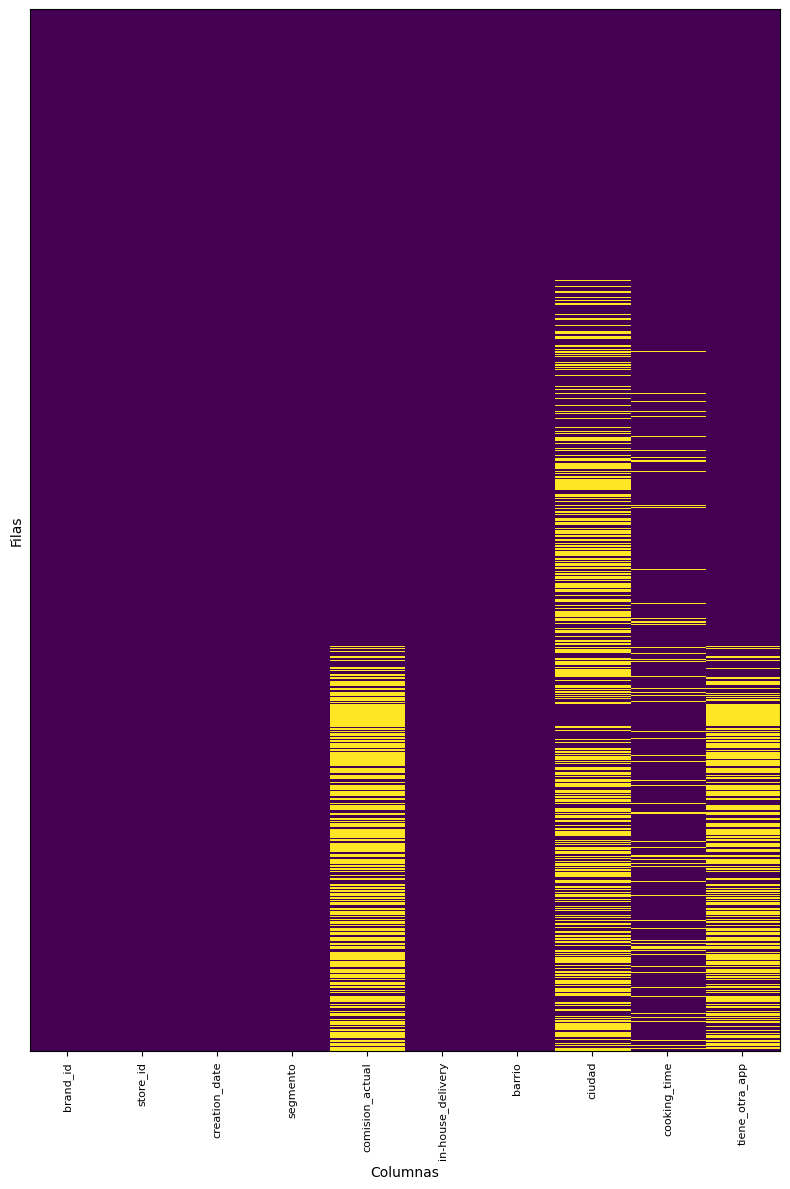

In [601]:
# matriz de missingness (visual)

# máscara (1 = falta, 0 = presente)
mask = df_stores.isna().astype(int)

# tamaño de figura ajustable según número de columnas/filas
fig, ax = plt.subplots(figsize=(max(8, 0.25*mask.shape[1]), min(12, 0.25*mask.shape[0])))

ax.imshow(mask, aspect='auto', interpolation='none')

# nombres de columnas en el eje x
ax.set_xticks(np.arange(mask.shape[1]))
ax.set_xticklabels(df_stores.columns, rotation=90, ha='center', fontsize=8)

# mostrar índices/filas solo si no son demasiadas (si hay muchas filas mejor ocultarlos)
if mask.shape[0] <= 60:
    ax.set_yticks(np.arange(mask.shape[0]))
    ax.set_yticklabels(df_stores.index, fontsize=6)
else:
    ax.set_yticks([])

ax.set_xlabel('Columnas')
ax.set_ylabel('Filas')
plt.tight_layout()
plt.show()

Pareciera que a partir de cierta fila empeizan a haber missings en comision actual y tiene_otra_app. Podria quiza ser por un componente temporal o de como esta ordenando el df

##### Relación entre missings y temporalidad

¿Las filas registradas en épocas tempranas al lanzamiento de MP delivery tienen más faltantes que las registradas mas actualmente?

In [602]:
df_stores['creation_date'] = pd.to_datetime(df_stores['creation_date'])

# variables tiempo
df_stores['creation_ym'] = df_stores['creation_date'].dt.to_period('M').astype(str)   # '2023-09'
df_stores['creation_month'] = df_stores['creation_date'].dt.to_period('M').astype(str)
df_stores['creation_week'] = df_stores['creation_date'].dt.to_period('W').dt.start_time

# tiempo continuo desde el primer registro (en días)
df_stores['days_since_first'] = (df_stores['creation_date'] - df_stores['creation_date'].min()).dt.days

In [603]:
cols_missing = miss_pct[miss_pct > 0].index.tolist()

In [604]:
missing_by_period = (
    df_stores.groupby('creation_month')[cols_missing]
      .apply(lambda g: g.isna().mean())
      .sort_index()
)

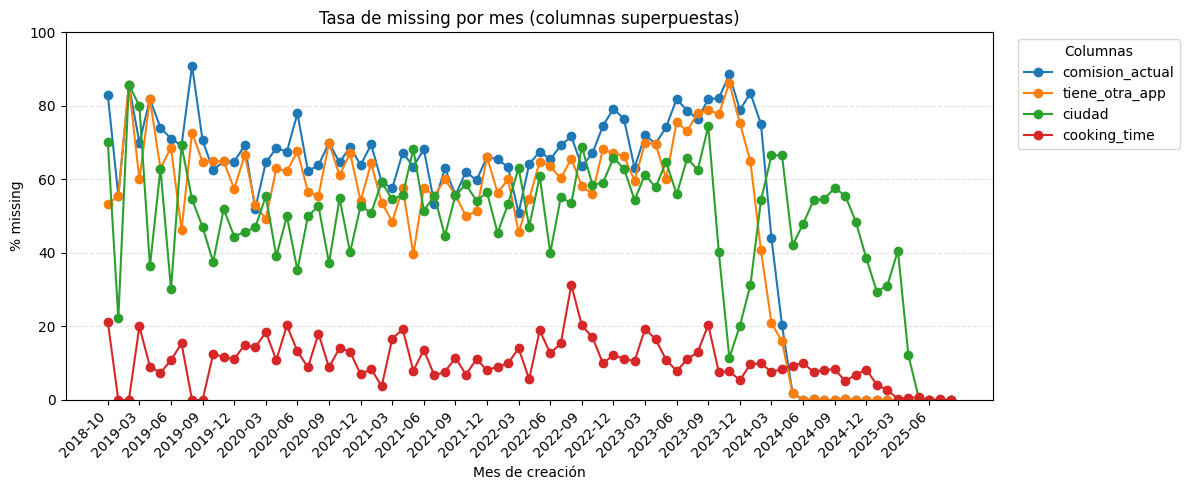

In [605]:
# plot
x_labels = missing_by_period.index.tolist()
x_pos = np.arange(len(x_labels))

plt.figure(figsize=(12,5))
for col in cols_missing:
    y = missing_by_period[col].values * 100
    plt.plot(x_pos, y, marker='o', linewidth=1.5, label=col)

# reducir etiquetas a máximo 30 para que no se amontonen
max_labels = 30
if len(x_pos) > max_labels:
    step = math.ceil(len(x_pos) / max_labels)
    xtick_pos = x_pos[::step]
else:
    xtick_pos = x_pos
xtick_labels = [x_labels[i] for i in xtick_pos]

plt.xticks(xtick_pos, xtick_labels, rotation=45, ha='right')
plt.ylabel('% missing')
plt.xlabel('Mes de creación')
plt.ylim(0, 100)
plt.title('Tasa de missing por mes (columnas superpuestas)')
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.legend(title='Columnas', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Se observa una clara relacion entre la antiguedad de las stores y la presencia de missing.

Se podrian eliminar aquellas stores anteriores a Mayo 2024 (05-2024). Esto va en linea con el hecho de que la popularidad de MP Delivery creció en 2024 por lo que su consistencia e integridad de datos se consolidó y estandarizó como proceso.

In [606]:
# correlación entre indicadores de faltante
miss_corr = df_complete[cols_missing].isna().astype(int).corr()

miss_corr

,comision_actual,tiene_otra_app,ciudad,cooking_time
comision_actual,1.000000,0.774174,0.287019,0.041181
tiene_otra_app,0.774174,1.000000,0.042795,0.071593
ciudad,0.287019,0.042795,1.000000,0.042760
cooking_time,0.041181,0.071593,0.042760,1.000000


La evolución temporal de la tasa de missing se comprueba tambien al ver la fuerte correlacion entre comisión actual y tiene_otra_app. 

Estas features probablemetne se volvieron obligatorias para los stores a partir del año pasado (2024).

In [607]:
# definir el corte
corte = pd.Timestamp("2024-04-30")

# filtrar (posteriores a abril 2024 → es decir >= 2024-05-01)
df_complete_filtrado = df_complete[df_complete['creation_date'] > corte].copy()

In [608]:
miss_pct_filtrado = df_complete_filtrado.isna().mean().sort_values(ascending=False)
miss_pct_filtrado[miss_pct_filtrado > 0]

ciudad             0.150340
cooking_time       0.051462
tiene_otra_app     0.002134
comision_actual    0.002134
dtype: float64

Ciudad es facil de imputar los outliers manualmente a partir del barrio

In [609]:
# considerar NaN o strings vacíos como "ciudad vacía"
mask_ciudad_vacia = df_complete_filtrado['ciudad'].isna() | (df_complete_filtrado['ciudad'].str.strip() == '')

# barrios únicos en esas filas
barrios_unicos = df_complete_filtrado.loc[mask_ciudad_vacia, 'barrio'].dropna().unique()

# ordenados alfabéticamente
barrios_unicos = sorted(barrios_unicos)

barrios_unicos

['acassuso',
 'agronomia',
 'almagro',
 'avellaneda',
 'balvanera',
 'barracas',
 'beccar',
 'belgrano',
 'boedo',
 'caballito',
 'carapachay',
 'chacarita',
 'ciudadela',
 'coghlan',
 'colegiales',
 'constitucion',
 'crucesita',
 'flores',
 'floresta',
 'florida',
 'florida oeste',
 'gerli',
 'la boca',
 'la lucila',
 'la plata',
 'liniers',
 'lomas del mirador',
 'martinez',
 'mataderos',
 'monserrat',
 'monte castro',
 'munro',
 'nueva pompeya',
 'nunez',
 'olivos',
 'palermo',
 'parque avellaneda',
 'parque chacabuco',
 'parque chas',
 'parque patricios',
 'paternal',
 'pineyro',
 'ramos mejia',
 'recoleta',
 'retiro',
 'saavedra',
 'san cristobal',
 'san isidro',
 'san martin centro',
 'san nicolas',
 'san telmo',
 'velez sarsfield',
 'vicente lopez',
 'villa adelina',
 'villa crespo',
 'villa del parque',
 'villa devoto',
 'villa general mitre',
 'villa lugano',
 'villa luro',
 'villa lynch',
 'villa martelli',
 'villa ortuzar',
 'villa pueyrredon',
 'villa real',
 'villa santa r

In [610]:
df_complete_filtrado['ciudad'].unique()

array([nan, 'Capital Federal', 'Buenos Aires', 'Córdoba'], dtype=object)

In [611]:
# 1. construir un diccionario barrio -> ciudad (usando la moda)
barrio_to_ciudad = (
    df_complete_filtrado
    .dropna(subset=['ciudad'])              # solo filas con ciudad no nula
    .groupby('barrio')['ciudad']
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

In [612]:
# 2. imputar: si ciudad es NaN, reemplazar usando el dict
df_complete_filtrado['ciudad'] = df_complete_filtrado.apply(
    lambda row: barrio_to_ciudad.get(row['barrio'], row['ciudad']),
    axis=1
)

In [613]:
# 3. barrios que quedaron sin imputar (ciudad sigue NaN)
barrios_sin_imputar = (
    df_complete_filtrado.loc[df_complete_filtrado['ciudad'].isna(), 'barrio']
    .dropna()
    .unique()
    .tolist()
)

print("Barrios que no pudieron imputarse:", barrios_sin_imputar)

Barrios que no pudieron imputarse: []


In [614]:
miss_pct_filtrado_final = df_complete_filtrado.isna().mean().sort_values(ascending=False)
miss_pct_filtrado_final[miss_pct_filtrado_final > 0]

cooking_time       0.051462
tiene_otra_app     0.002134
comision_actual    0.002134
dtype: float64

In [615]:
df_complete_filtrado.shape

(565663, 17)

In [616]:
df_complete.shape

(1715572, 17)

#### Análisis exploratorio univariado

In [617]:
df_complete_filtrado.describe()

,store_id,orders_date,avg_shipping_cost,free_shipping,total_products_number,total_products_value,gross_merchant_value,brand_id,creation_date,comision_actual,in-house_delivery,cooking_time,tiene_otra_app
count,565663.00000,565663,565663.000000,565663.000000,565663.000000,5.656630e+05,5.656630e+05,565663.000000,565663,564456.000000,565663.000000,536553.0,564456.0
mean,107660.82081,2025-04-23 02:44:33.491460352,1463.937975,0.854656,16.824751,5.221377e+05,2.586605e+05,13311.465823,2024-11-28 12:28:08.018484736,30.717995,0.046731,17.804989,0.839314
min,100001.00000,2024-01-01 00:00:00,1000.000000,0.000000,4.000000,1.300340e+03,3.792830e+03,10001.000000,2024-05-01 00:00:00,0.000000,0.000000,0.0,0.0
25%,103734.00000,2025-02-22 00:00:00,1299.860000,1.000000,5.000000,8.766148e+04,6.264094e+04,11674.000000,2024-08-09 00:00:00,24.000000,0.000000,10.0,1.0
50%,107662.00000,2025-05-24 00:00:00,1382.610000,1.000000,6.000000,1.979338e+05,1.145225e+05,13250.000000,2024-12-04 00:00:00,30.000000,0.000000,20.0,1.0
75%,111633.00000,2025-07-12 00:00:00,1657.950000,1.000000,16.000000,4.932875e+05,2.442527e+05,14914.000000,2025-03-18 00:00:00,42.000000,0.000000,20.0,1.0
max,115232.00000,2025-08-20 00:00:00,3000.000000,1.000000,1048.000000,4.232241e+07,1.671915e+07,16981.000000,2025-08-13 00:00:00,46.500000,1.000000,115.0,1.0
std,4447.55267,NaN,220.387913,0.352448,30.365958,1.095557e+06,4.954507e+05,1902.447974,NaN,9.604275,0.211062,7.232258,0.367241


In [618]:
df_complete_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 565663 entries, 541 to 1715571
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   store_id               565663 non-null  int64         
 1   orders_date            565663 non-null  datetime64[ns]
 2   app_origin             565663 non-null  object        
 3   avg_shipping_cost      565663 non-null  float64       
 4   free_shipping          565663 non-null  int64         
 5   total_products_number  565663 non-null  int64         
 6   total_products_value   565663 non-null  float64       
 7   gross_merchant_value   565663 non-null  float64       
 8   brand_id               565663 non-null  int64         
 9   creation_date          565663 non-null  datetime64[ns]
 10  segmento               565663 non-null  object        
 11  comision_actual        564456 non-null  float64       
 12  in-house_delivery      565663 non-null  int64 

In [619]:
# Filtrar solo las columnas numéricas
numeric_cols = df_complete_filtrado.select_dtypes(include=['number']).columns

# Lista de columnas a excluir
cols_excluir = ['store_id', 'free_shipping', 'in-house_delivery', 'tiene_otra_app']

# Filtrar
numeric_cols = [col for col in numeric_cols if col not in cols_excluir]

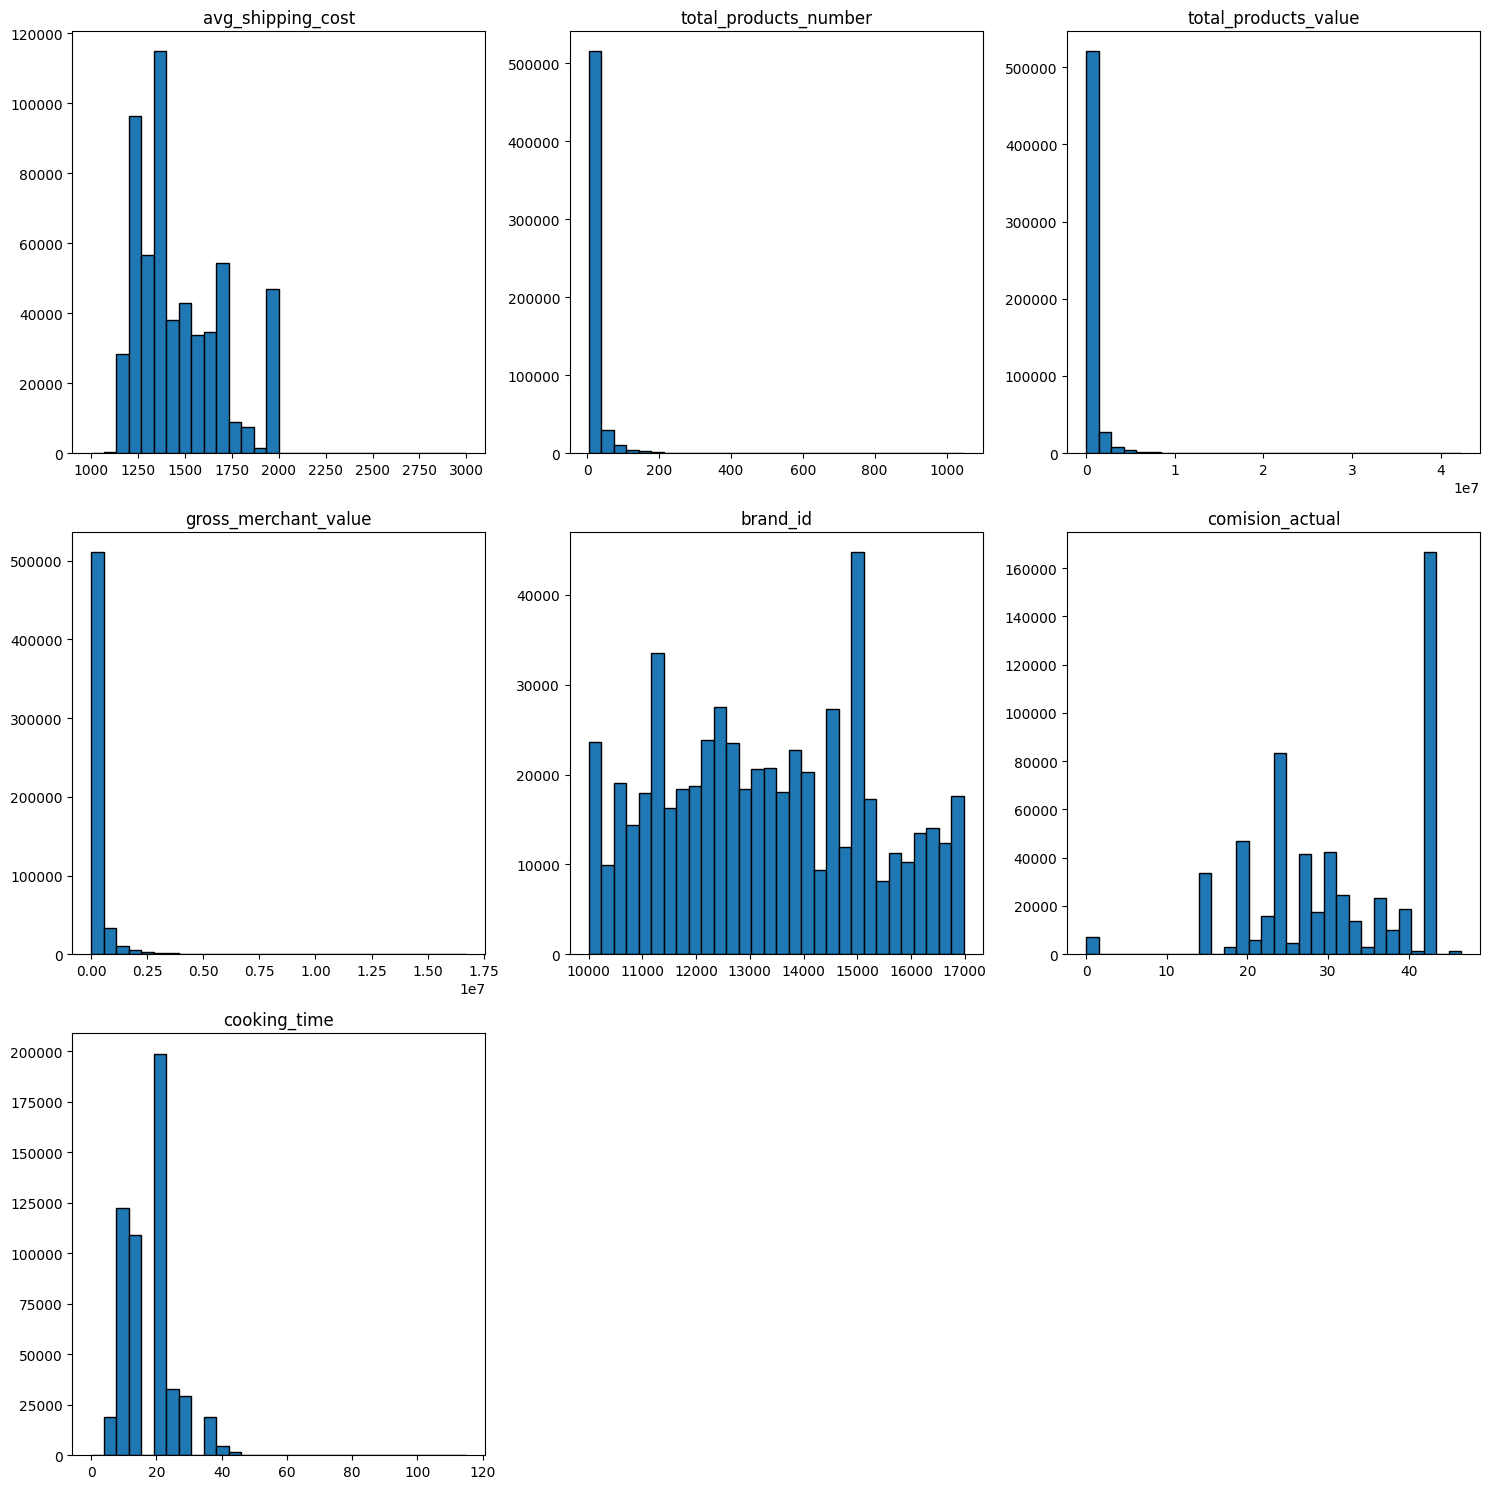

In [620]:
# Definir tamaño de la cuadrilla (aprox. cuadrada)
n = len(numeric_cols)
ncols = 3  # cantidad de columnas que querés en la cuadrilla
nrows = (n + ncols - 1) // ncols

# Crear figura
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
axes = axes.flatten()  # aplanar para iterar fácil

# Graficar cada histograma
for i, col in enumerate(numeric_cols):
    axes[i].hist(df_complete_filtrado[col].dropna(), bins=30, edgecolor="black")
    axes[i].set_title(col)

# Eliminar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Análisis exploratorio bivariado y multivariado

##### Correlaciones numericas

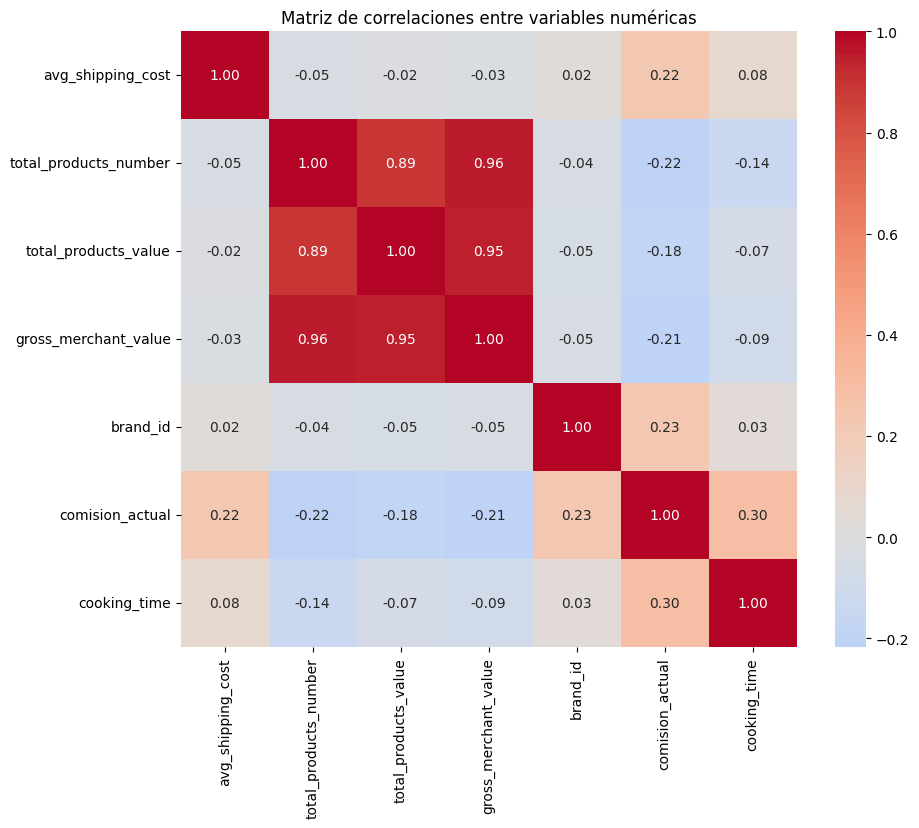

In [ ]:
# Calcular matriz de correlación
corr = df_complete_filtrado[numeric_cols].corr(method='pearson')

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlaciones entre variables numéricas")
plt.show()

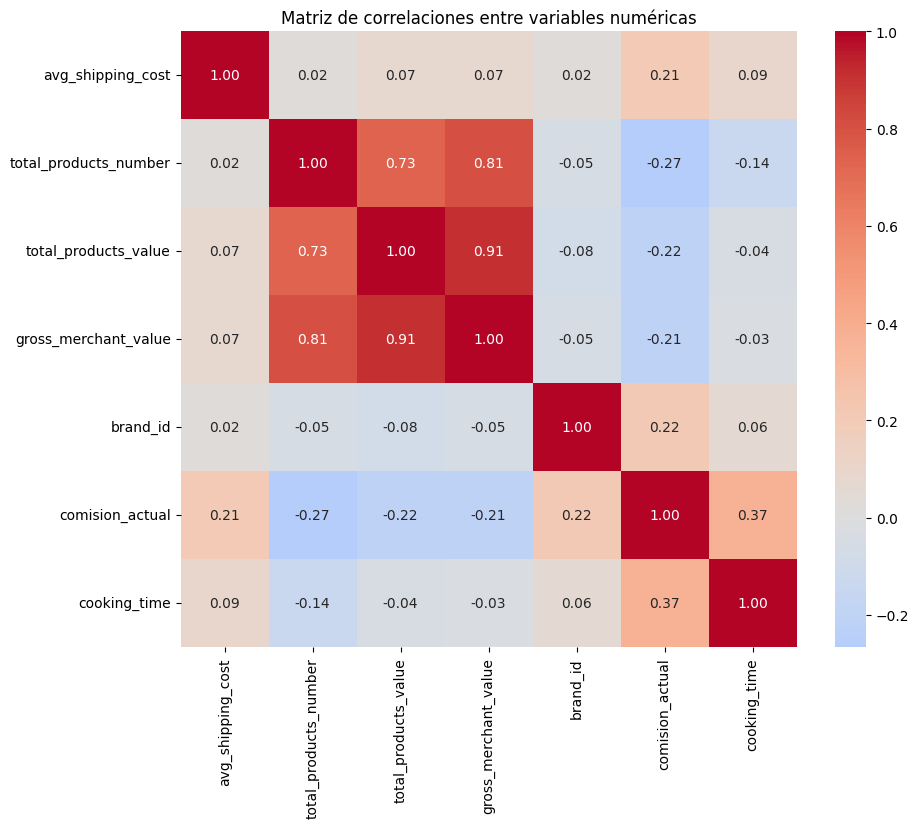

In [625]:
# Calcular matriz de correlación
corr = df_complete_filtrado[numeric_cols].corr(method='spearman')

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlaciones entre variables numéricas")
plt.show()

#### Nuevas features

##### Antigüedad (*order_date* y *creation_date*)

In [ ]:
# máscara de filas válidas
mask = df_complete_filtrado["creation_date"].notna() & df_complete_filtrado["orders_date"].notna()

In [ ]:
# 1) días totales (vectorizado)
df_complete_filtrado.loc[mask, "antiguedad_dias"] = (df_complete_filtrado.loc[mask, "orders_date"] - df_complete_filtrado.loc[mask, "creation_date"]).dt.days.astype("Int64")

In [ ]:
# 2) meses totales completos (vectorizado)
years_diff  = df_complete_filtrado["orders_date"].dt.year  - df_complete_filtrado["creation_date"].dt.year
months_diff = df_complete_filtrado["orders_date"].dt.month - df_complete_filtrado["creation_date"].dt.month
total_months = years_diff * 12 + months_diff
# restar 1 mes si el día del pedido es anterior al día de creación (aún no completó ese mes)
total_months = total_months - (df_complete_filtrado["orders_date"].dt.day < df_complete_filtrado["creation_date"].dt.day).astype("Int64")
df_complete_filtrado.loc[mask, "antiguedad_meses"] = total_months

In [ ]:
# 3) años completos (vectorizado)
years = df_complete_filtrado["orders_date"].dt.year - df_complete_filtrado["creation_date"].dt.year
# restar 1 si no completó el año (mes anterior o mismo mes pero día anterior)
not_completed_year = (
    (df_complete_filtrado["orders_date"].dt.month  < df_complete_filtrado["creation_date"].dt.month) |
    ((df_complete_filtrado["orders_date"].dt.month == df_complete_filtrado["creation_date"].dt.month) & 
     (df_complete_filtrado["orders_date"].dt.day  < df_complete_filtrado["creation_date"].dt.day))
)
years = years - not_completed_year.astype("Int64")
df_complete_filtrado.loc[mask, "antiguedad_anios"] = years

In [ ]:
df_complete_filtrado.head()

,store_id,orders_date,app_origin,avg_shipping_cost,free_shipping,total_products_number,total_products_value,gross_merchant_value,brand_id,creation_date,segmento,comision_actual,in-house_delivery,barrio,ciudad,cooking_time,tiene_otra_app,antiguedad_dias,antiguedad_meses,antiguedad_anios
541,101514,2024-01-04,MP_IOS_WALLET,1086.84,1,5,87862.56,20994.50,11465,2024-10-28,Microstores,NaN,0,belgrano,Capital Federal,15,<NA>,-298,-10,-1
1288,101514,2024-01-06,MP_ANDROID_WALLET,1078.52,1,62,1536578.42,577394.13,11465,2024-10-28,Microstores,NaN,0,belgrano,Capital Federal,15,<NA>,-296,-10,-1
1525,101514,2024-01-02,MP_IOS_WALLET,1068.96,1,18,466951.26,116211.87,11465,2024-10-28,Microstores,NaN,0,belgrano,Capital Federal,15,<NA>,-300,-10,-1
1577,101514,2024-01-02,MP_ANDROID_WALLET,1035.76,1,27,443927.80,163574.60,11465,2024-10-28,Microstores,NaN,0,belgrano,Capital Federal,15,<NA>,-300,-10,-1
1954,101514,2024-01-05,MP_IOS_WALLET,1071.03,1,18,962973.40,140952.55,11465,2024-10-28,Microstores,NaN,0,belgrano,Capital Federal,15,<NA>,-297,-10,-1


ver que de por qué hay registros de ordenes de tiendas que estan registradas en MP Delivery despues la ocurrencia de la orden??